In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohamedbakrey/housecsv/houses.csv


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import chi2,f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import median_absolute_error
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import zero_one_loss

In [4]:
#load dataset
df=pd.read_csv('/kaggle/input/datasets/mohamedbakrey/housecsv/houses.csv')

In [5]:
# Displays the first 5 rows of the dataset 
df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,53.80
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,60.40
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00


In [6]:
#Checks for missing values in each column
print(df.isnull().sum())

bedrooms         1
bathrooms        1
sqft_living      1
sqft_lot         1
floors           1
waterfront       1
view             1
condition        1
grade            1
sqft_above       1
sqft_basement    1
yr_built         1
yr_renovated     1
zipcode          1
lat              1
long             1
sqft_living15    1
price            1
dtype: int64


In [7]:
#replaces all missing values with 0 to handle missing value
def data_clean(df):
    df.fillna(0,inplace=True)
    print(df.isnull().sum())

In [8]:
#Calls the data cleaning function to
data_clean(df)

bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
price            0
dtype: int64


In [9]:
#Prints unique values of selected columns to understand data categories.
list=['price','condition','grade']

for i in list:
    print('{} has unique values as {}'.format(i,df[i].unique()))

price has unique values as [ 22.19    53.8     18.      60.4     51.     123.      25.75    29.185
  22.95    32.3     66.25    46.8     31.      40.      53.      65.
  39.5     48.5     18.9     23.      38.5    200.      28.5     25.27
  32.9     23.3     93.7     66.7     43.8     71.9     58.05    28.
  68.75    53.5     32.25    69.6     55.      64.      24.      60.5
  62.5     77.5     86.199   68.5     30.9     48.8     21.049   78.5
  45.     135.      22.8     34.5     60.      58.5     92.      88.5
  29.25    30.1     95.1     43.      28.9     50.5     54.9     42.5
  31.7625  97.5     28.7     20.4    133.     104.      32.5     57.1
  36.      34.9     83.25    38.      48.      41.      72.      39.
  35.5     35.6     31.5     94.      30.5     46.1     21.5     33.5
  24.35   110.      15.3     70.      90.5     24.75    19.9     31.4
  43.75    85.083   55.5     69.995  109.      29.      37.5     46.
  18.85    68.      47.      59.775   57.      27.25    32.995  

In [10]:
#dentify invalid or missing price values
len(df[df['price']==0])

1

In [11]:
#setting Shows up to 32 columns in output.
pd.set_option('display.max_columns',32)

In [12]:
#Filters rows where condition, price, and grade are all 0 to identify invalid record
filter=(df['condition']==0) & (df['price']==0) & (df['grade']==0)
df[filter]

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
#removes invalid records
data=df[~filter]

In [14]:
#Displays the first 5 rows of the cleaned dataset
data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,53.80
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,60.40
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00


In [15]:
#Generates summary statistics of the dataset
data.describe()


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,3.349349,2.045796,2051.397397,14707.242242,1.446947,0.008008,0.237237,3.464464,7.605606,1750.233233,301.164164,1969.030030,81.830831,98074.441441,47.549720,-122.207406,1986.813814,52.071452
std,0.852367,0.721983,888.351113,28975.077254,0.517420,0.089173,0.765472,0.689521,1.160734,790.466905,451.023402,28.198607,395.767918,52.545832,0.141558,0.139564,670.723475,33.974907
min,0.000000,0.000000,380.000000,649.000000,1.000000,0.000000,0.000000,1.000000,4.000000,380.000000,0.000000,1900.000000,0.000000,98001.000000,47.177500,-122.490000,830.000000,8.000000
25%,3.000000,1.500000,1405.000000,5419.000000,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1952.000000,0.000000,98032.000000,47.443000,-122.322500,1490.000000,30.980000
50%,3.000000,2.000000,1900.000000,8040.000000,1.000000,0.000000,0.000000,3.000000,7.000000,1540.000000,0.000000,1974.000000,0.000000,98058.000000,47.563600,-122.218000,1850.000000,43.500000
75%,4.000000,2.500000,2475.000000,11508.500000,2.000000,0.000000,0.000000,4.000000,8.000000,2135.000000,580.000000,1992.000000,0.000000,98116.000000,47.673400,-122.118000,2360.000000,63.446250
max,7.000000,5.000000,6070.000000,315374.000000,3.500000,1.000000,4.000000,5.000000,12.000000,6070.000000,2060.000000,2015.000000,2014.000000,98199.000000,47.777600,-121.709000,4760.000000,308.000000


In [16]:
#Resets the index of the ‘lat’ column and converts it into a DataFrame
df['lat'].reset_index()

,index,lat
0,0,47.5112
1,1,47.7210
2,2,47.7379
3,3,47.5208
4,4,47.6168
...,...,...
995,995,47.3492
996,996,47.2786
997,997,47.6707
998,998,47.3738


In [17]:
#Resets the index of the price column and converts it into a DataFrame.
df['price'].reset_index()

,index,price
0,0,22.190
1,1,53.800
2,2,18.000
3,3,60.400
4,4,51.000
...,...,...
995,995,29.100
996,996,19.995
997,997,55.350
998,998,18.995


Compere The every columns to price to see how each columns effict the price

In [18]:
house_bathroom=df.groupby(['bathrooms'])['price'].mean().reset_index()
house_bathroom




,bathrooms,price
0,0.00,55.000000
1,0.75,26.319167
2,1.00,36.202367
3,1.25,39.750000
4,1.50,37.391187
5,1.75,42.498923
6,2.00,44.541653
7,2.25,53.397108
8,2.50,58.082415
9,2.75,62.707463


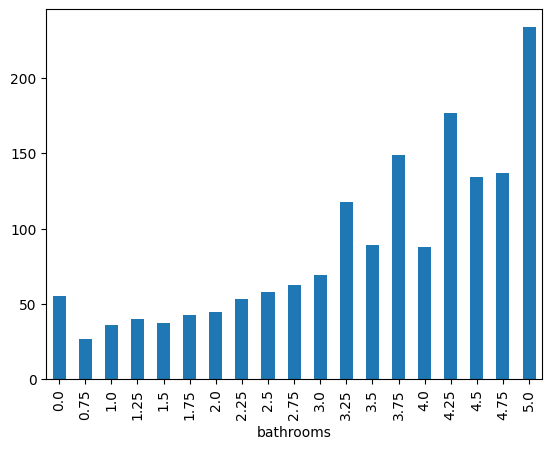

In [19]:
house_bathroom=df.groupby(['bathrooms'])['price'].mean().plot(kind='bar')

In [33]:
house_bedrooms=df.groupby(['bedrooms'])['price'].mean().reset_index()
house_bedrooms

,bedrooms,price
0,0.0,55.000000
1,1.0,24.298571
2,2.0,39.533956
3,3.0,45.374242
4,4.0,61.712832
5,5.0,75.243522
6,6.0,67.677273
7,7.0,195.000000


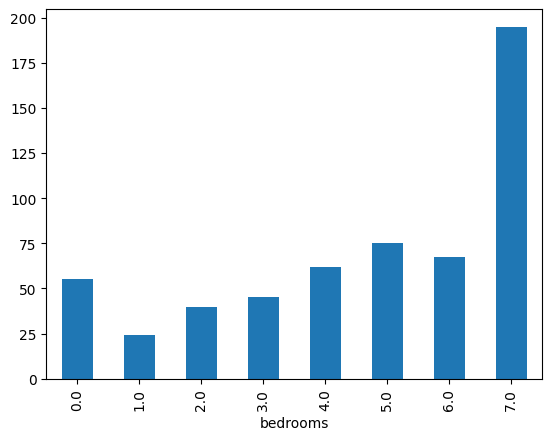

In [20]:
house_bedrooms=df.groupby(['bedrooms'])['price'].mean().plot(kind='bar')

In [21]:
house_sqft_living=df.groupby(['sqft_living'])['price'].mean().reset_index()
house_sqft_living

,sqft_living,price
0,0.0,0.00
1,380.0,24.50
2,430.0,8.00
3,560.0,29.90
4,630.0,25.25
...,...,...
317,5310.0,137.00
318,5403.0,213.00
319,5420.0,123.00
320,6050.0,126.50


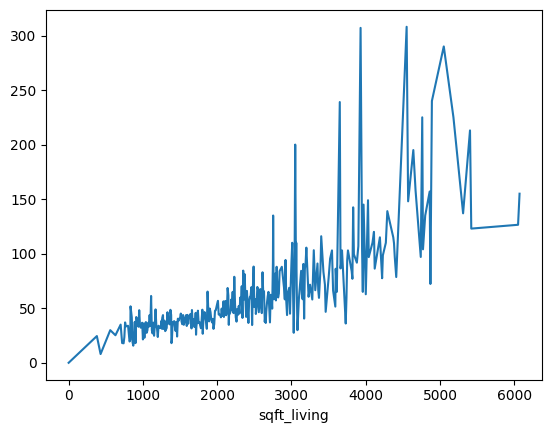

In [22]:
house_sqft_living=df.groupby(['sqft_living'])['price'].mean().plot()

In [37]:
house_sqft_lot=df.groupby(['sqft_lot'])['price'].mean().reset_index()
house_sqft_lot

,sqft_lot,price
0,0.0,0.000
1,649.0,25.995
2,1016.0,53.500
3,1044.0,54.900
4,1058.0,46.600
...,...,...
824,219978.0,35.000
825,221284.0,80.000
826,230652.0,160.000
827,262018.0,39.000


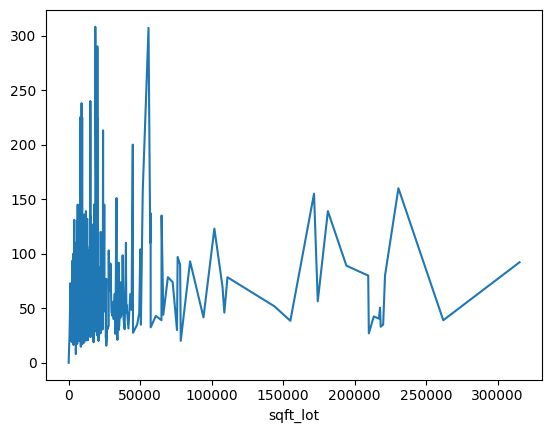

In [23]:
house_sqft_lot=df.groupby(['sqft_lot'])['price'].mean().plot()

In [24]:
house_waterfront=df['waterfront'].value_counts().reset_index()
house_waterfront.columns=['price','waterfront']
house_waterfront

,price,waterfront
0,0.0,992
1,1.0,8


Select important Features using Co-relation

<Axes: >

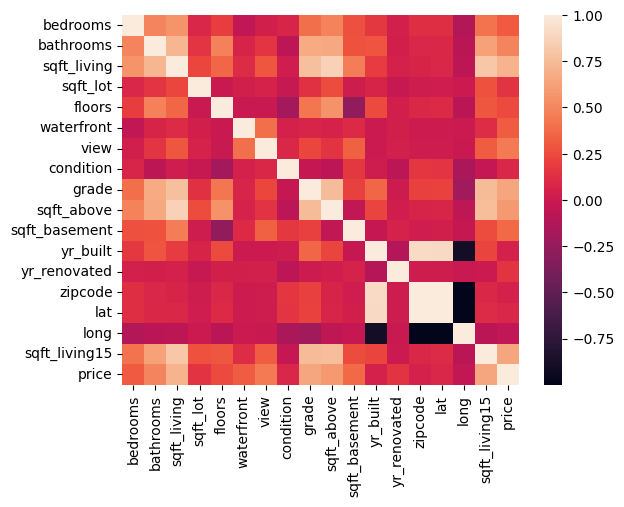

In [25]:
df1=df.corr()
sns.heatmap(df1,annot=None,fmt="")

In [26]:
co_relation=data.corr()["price"]
co_relation

bedrooms         0.306886
bathrooms        0.487360
sqft_living      0.704948
sqft_lot         0.146680
floors           0.239497
waterfront       0.317311
view             0.445190
condition        0.073413
grade            0.647845
sqft_above       0.582805
sqft_basement    0.367061
yr_built         0.016690
yr_renovated     0.146249
zipcode         -0.066212
lat              0.365141
long             0.032656
sqft_living15    0.645747
price            1.000000
Name: price, dtype: float64

In [27]:
co_relation.abs().sort_values(ascending=False)

price            1.000000
sqft_living      0.704948
grade            0.647845
sqft_living15    0.645747
sqft_above       0.582805
bathrooms        0.487360
view             0.445190
sqft_basement    0.367061
lat              0.365141
waterfront       0.317311
bedrooms         0.306886
floors           0.239497
sqft_lot         0.146680
yr_renovated     0.146249
condition        0.073413
zipcode          0.066212
long             0.032656
yr_built         0.016690
Name: price, dtype: float64

In [28]:
co_relation.abs().sort_values(ascending=False)[1:]

sqft_living      0.704948
grade            0.647845
sqft_living15    0.645747
sqft_above       0.582805
bathrooms        0.487360
view             0.445190
sqft_basement    0.367061
lat              0.365141
waterfront       0.317311
bedrooms         0.306886
floors           0.239497
sqft_lot         0.146680
yr_renovated     0.146249
condition        0.073413
zipcode          0.066212
long             0.032656
yr_built         0.016690
Name: price, dtype: float64

In [29]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

Perform Mean Encoding Technique

In [30]:
cols=df.columns[0:8]
cols

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition'],
      dtype='object')

In [31]:
for col in cols:
    print(df.groupby([col])['view'].mean())
    print('\n')

bedrooms
0.0    1.000000
1.0    0.571429
2.0    0.219298
3.0    0.209776
4.0    0.236066
5.0    0.333333
6.0    0.636364
7.0    1.000000
Name: view, dtype: float64


bathrooms
0.00    1.000000
0.75    0.666667
1.00    0.080214
1.25    3.000000
1.50    0.147541
1.75    0.238994
2.00    0.183673
2.25    0.173077
2.50    0.260504
2.75    0.176471
3.00    0.545455
3.25    0.833333
3.50    0.428571
3.75    0.000000
4.00    0.500000
4.25    0.750000
4.50    1.000000
4.75    0.000000
5.00    3.500000
Name: view, dtype: float64


sqft_living
0.0       0.0
380.0     0.0
430.0     0.0
560.0     0.0
630.0     0.0
         ... 
5310.0    0.0
5403.0    4.0
5420.0    0.0
6050.0    2.5
6070.0    0.0
Name: view, Length: 322, dtype: float64


sqft_lot
0.0         0.0
649.0       0.0
1016.0      0.0
1044.0      0.0
1058.0      0.0
           ... 
219978.0    0.0
221284.0    0.0
230652.0    3.0
262018.0    0.0
315374.0    0.0
Name: view, Length: 829, dtype: float64


floors
0.0    0.000000
1.0    0.25378

In [32]:
df3=data.copy()

In [33]:
for col in cols:
    dict=data.groupby([col])['price'].mean().to_dict()
    data[col]=data[col].map(dict)

In [34]:
df3.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,53.80
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,60.40
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00


<Axes: xlabel='price', ylabel='Density'>

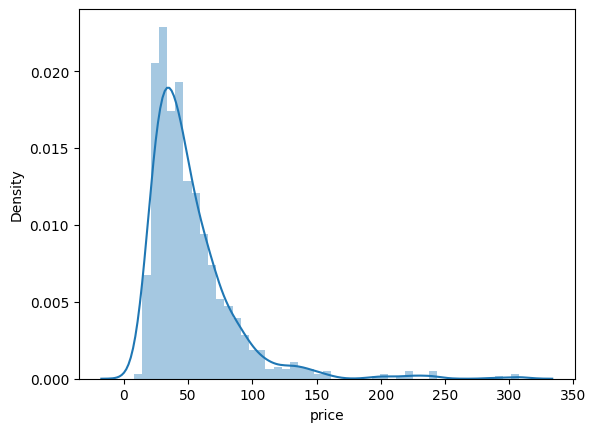

In [35]:
sns.distplot(data['price'])

In [36]:
def handle_outlier(col):
    data[col]=np.log1p(data[col])

In [37]:
handle_outlier('price')

<Axes: xlabel='price', ylabel='Density'>

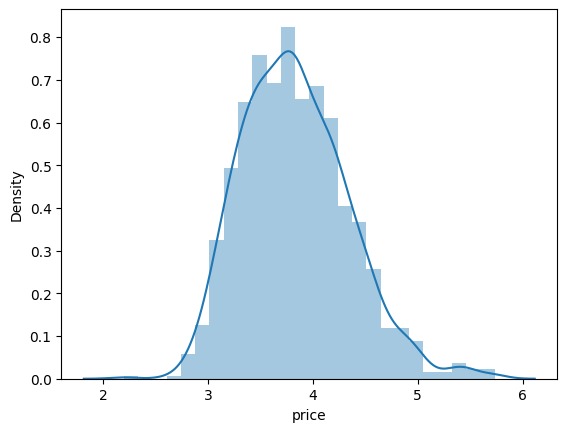

In [38]:
sns.distplot(data['price'].dropna())

<Axes: xlabel='view', ylabel='Density'>

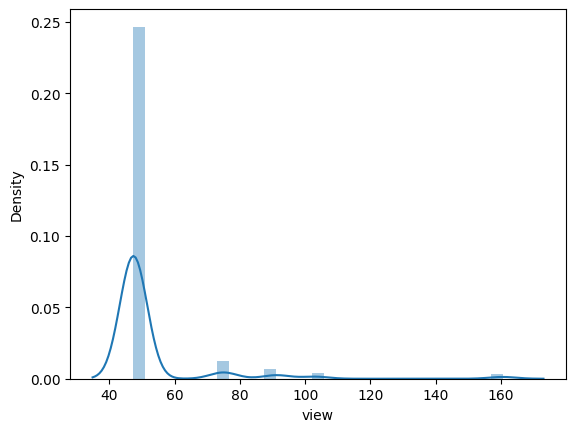

In [39]:
sns.distplot(data['view'])

In [40]:
df.drop(['view','yr_built','yr_renovated','zipcode','long','sqft_living15','waterfront','sqft_living','sqft_lot','sqft_above','sqft_basement'],axis=1,inplace=True)

In [41]:
X = df.iloc[:,:-1] 
y = df.iloc[:, -1]


In [42]:
 X[:10]

,bedrooms,bathrooms,floors,condition,grade,lat
0,3.0,1.00,1.0,3.0,7.0,47.5112
1,3.0,2.25,2.0,3.0,7.0,47.7210
2,2.0,1.00,1.0,3.0,6.0,47.7379
3,4.0,3.00,1.0,5.0,7.0,47.5208
4,3.0,2.00,1.0,3.0,8.0,47.6168
5,4.0,4.50,1.0,3.0,11.0,47.6561
6,3.0,2.25,2.0,3.0,7.0,47.3097
7,3.0,1.50,1.0,3.0,7.0,47.4095
8,3.0,1.00,1.0,3.0,7.0,47.5123
9,3.0,2.50,2.0,3.0,7.0,47.3684


In [43]:
y[:10]

0     22.190
1     53.800
2     18.000
3     60.400
4     51.000
5    123.000
6     25.750
7     29.185
8     22.950
9     32.300
Name: price, dtype: float64

In [55]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 44,shuffle=True)


In [56]:
X_train

,bedrooms,bathrooms,floors,condition,grade,lat
357,4.0,1.00,1.5,4.0,7.0,47.5759
645,3.0,1.75,1.0,3.0,7.0,47.3647
271,2.0,1.00,1.0,4.0,7.0,47.7107
400,3.0,3.50,2.0,3.0,8.0,47.6055
342,3.0,1.75,1.0,3.0,8.0,47.7222
...,...,...,...,...,...,...
571,4.0,4.00,2.0,3.0,10.0,47.5816
173,4.0,2.50,2.0,3.0,10.0,47.6477
753,2.0,2.50,1.0,3.0,8.0,47.7170
419,5.0,4.25,2.0,3.0,12.0,47.5954


In [57]:
X_test

,bedrooms,bathrooms,floors,condition,grade,lat
118,4.0,2.00,1.0,3.0,6.0,47.4965
19,3.0,1.00,1.0,4.0,7.0,47.3343
41,4.0,2.25,1.0,3.0,8.0,47.4450
425,3.0,2.50,1.0,5.0,7.0,47.3592
221,3.0,2.00,1.0,3.0,7.0,47.3980
...,...,...,...,...,...,...
191,3.0,1.00,1.0,3.0,6.0,47.4616
561,4.0,2.25,1.0,4.0,8.0,47.2953
595,3.0,1.75,1.0,3.0,7.0,47.4920
780,3.0,1.00,1.0,5.0,7.0,47.4750


In [58]:
# Fitting Simple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [59]:
regressor.score(X_train, y_train)
regressor.score(X_test, y_test)

0.38995133960442996

In [62]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)
y_pred[:10]

array([21.00486739, 41.34682173, 57.74594113, 52.7692537 , 38.07640101,
       81.81502781, 48.33019261, 54.30469746, 53.59666303, 36.71485828])

In [63]:
# calculate the mean_squard_error

mean_absolute_error(y_test, y_pred)

17.156660048363005

In [64]:
# calculate the median_absolute_error
from sklearn.metrics import median_absolute_error
median_absolute_error(y_test, y_pred)

np.float64(12.426984035214035)

In [66]:
import joblib

joblib.dump(regressor, 'house_price_model.pkl')

['house_price_model.pkl']